In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import librosa
warnings.filterwarnings('ignore')

data_path = '/kaggle/input/datasets/tushaamagrawal/icbhi-2017-challenge/ICBHI_final_database'

print("Total files are:",len(os.listdir(data_path)))

wav_files = [f for f in os.listdir(data_path) if f.endswith('wav')]
txt_files = [f for f in os.listdir(data_path) if f.endswith('txt')]

print("Total wav files:",len(wav_files))
print("Total txt files:",len(txt_files))

wav_set = set([f.replace(".wav", "") for f in wav_files])
txt_set = set([f.replace(".txt","") for f in txt_files])

common_files = list(wav_set.intersection(txt_set))

print("Usable files:", len(common_files))

missing_txt = wav_set - txt_set
missing_wav = txt_set - wav_set

print("Total wav files without txt files:",missing_txt)
print("Total txt files without wav files:",missing_wav)


2026-05-31 16:09:36.852986: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780243777.050232      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780243777.106586      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780243777.575134      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780243777.575184      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780243777.575187      57 computation_placer.cc:177] computation placer alr

Total files are: 1843
Total wav files: 920
Total txt files: 922
Usable files: 920
Total wav files without txt files: set()
Total txt files without wav files: {'filename_format', 'filename_differences'}


In [3]:
import librosa
def extract_segment(start, end, sr, y):
    start_idx = int(start*sr)
    end_idx = int(end*sr)
    return y[start_idx:end_idx]
    


def process_audio(filename):
    audio_path = f"{data_path}/{filename}.wav"
    text_path  = f"{data_path}/{filename}.txt"

    y, sr = librosa.load(audio_path, sr=16000)

    segments = []
    labels = []

    with open(text_path, "r") as f:
        for line in f:
            start, end, crackle, wheeze = line.strip().split()

            start, end = float(start), float(end)
            crackle, wheeze = int(crackle), int(wheeze)

            segment = extract_segment(start, end, sr, y)

            if crackle == 0 and wheeze == 0:
                label = 0   # Normal
            elif crackle == 1 and wheeze == 0:
                label = 1   # Crackle
            elif crackle == 0 and wheeze == 1:
                label = 2   # Wheeze
            else:
                label = 3   # Both


            segments.append(segment)
            labels.append(label)

    return segments, labels, sr

In [4]:
import matplotlib.pyplot as plt

def to_mel_spec(signal, sr, n_mels=128):
    mel = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_mels=n_mels
    )
    return librosa.power_to_db(mel)

MAX_LEN = 128

def pad_spectrogram(spec):
    if spec.shape[1] < MAX_LEN:
        pad = MAX_LEN - spec.shape[1]
        spec = np.pad(spec, ((0,0),(0,pad)), mode='constant')
    else:
        spec = spec[:, :MAX_LEN]
    return spec

In [5]:
from sklearn.model_selection import train_test_split

train_files, test_files = train_test_split(
    common_files,
    test_size=0.2,
    random_state=42
)

def build_dataset(file_list):
    X, y = [], []

    for file in file_list:
        segments, labels, sr = process_audio(file)

        for seg, lab in zip(segments, labels):

            if len(seg) < 1000:
                continue

            spec = to_mel_spec(seg, sr)
            spec = pad_spectrogram(spec)

            X.append(spec)
            y.append(lab)

    X = np.array(X)[..., np.newaxis]
    y = np.array(y)

    return X, y

In [6]:
X_train, y_train = build_dataset(train_files)
X_test, y_test   = build_dataset(test_files)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (5596, 128, 128, 1) (5596,)
Test: (1302, 128, 128, 1) (1302,)


In [7]:
import numpy as np
import cv2

def prepare_resnet_input(X):
    
    X_resnet = []
    
    for img in X:
        img = img.squeeze()  # (128,128)

        # Resize
        img = cv2.resize(img, (224, 224))

        # Convert to 3 channels
        img = np.stack([img, img, img], axis=-1)

        X_resnet.append(img)
    
    return np.array(X_resnet)

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [9]:
X_train_res = prepare_resnet_input(X_train)
X_val_res   = prepare_resnet_input(X_val)
X_test_res  = prepare_resnet_input(X_test)

In [10]:
import tensorflow as tf
X_train_res = tf.image.resize(X_train, (224,224)).numpy()
X_train_res = np.repeat(X_train_res, 3, axis=-1)

X_val_res = tf.image.resize(X_val, (224,224)).numpy()
X_val_res = np.repeat(X_val_res, 3, axis=-1)

X_test_res = tf.image.resize(X_test, (224,224)).numpy()
X_test_res = np.repeat(X_test_res, 3, axis=-1)

I0000 00:00:1780243932.727385      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780243932.733555      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [11]:
unique, counts = np.unique(y_train, return_counts=True)
unique_classes = {"Normal": 0, "Crackle": 1, "Wheeze": 2, "Both": 3}

reverse_mapping = {v: k for k, v in unique_classes.items()}

class_counts = {reverse_mapping[u]: c for u, c in zip(unique, counts.tolist())}

print(class_counts)

{'Normal': 2694, 'Crackle': 1353, 'Wheeze': 639, 'Both': 350}


In [12]:
mean = np.mean(X_train)
std = np.std(X_train)

X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

from tensorflow.keras.applications.resnet50 import preprocess_input

X_train_res = preprocess_input(X_train_res)
X_val_res   = preprocess_input(X_val_res)
X_test_res  = preprocess_input(X_test_res)

In [13]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout,Input

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
base_model.trainable = False


inputs = Input(shape=(224,224,3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(4, activation='softmax')(x)

resnet_model = Model(inputs, outputs)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
history = resnet_model.fit(
    X_train_res, y_train,
    validation_data=(X_val_res, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50


I0000 00:00:1780243973.766409     138 service.cc:152] XLA service 0x7d0fb01558f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780243973.766469     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780243973.766477     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780243975.694764     138 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/158 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - accuracy: 0.1953 - loss: 2.0991

I0000 00:00:1780243981.143540     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


158/158 ━━━━━━━━━━━━━━━━━━━━ 42s 172ms/step - accuracy: 0.4296 - loss: 1.3740 - val_accuracy: 0.5661 - val_loss: 1.0227
Epoch 2/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 0.5532 - loss: 1.0695 - val_accuracy: 0.5839 - val_loss: 0.9962
Epoch 3/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.5856 - loss: 0.9998 - val_accuracy: 0.5893 - val_loss: 0.9856
Epoch 4/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - accuracy: 0.5865 - loss: 0.9896 - val_accuracy: 0.5946 - val_loss: 0.9629
Epoch 5/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.5879 - loss: 0.9792 - val_accuracy: 0.5893 - val_loss: 0.9478
Epoch 6/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - accuracy: 0.6056 - loss: 0.9514 - val_accuracy: 0.6125 - val_loss: 0.9383
Epoch 7/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.6166 - loss: 0.9149 - val_accuracy: 0.6036 - val_loss: 0.9318
Epoch 8/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 16s 103ms/step - accuracy: 0.6375 - loss: 0.9035 - val_ac

In [18]:
y_pred_prob = resnet_model.predict(X_test_res)

41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 244ms/step


In [19]:
def build_segments_with_ids(file_list):
    segments = []
    labels = []
    file_ids = []

    for file in file_list:
        audio_path = f"{data_path}/{file}.wav"
        text_path  = f"{data_path}/{file}.txt"

        y, sr = librosa.load(audio_path, sr=16000)

        with open(text_path, "r") as f:
            for line in f:
                start, end, crackle, wheeze = line.strip().split()

                start, end = float(start), float(end)
                crackle, wheeze = int(crackle), int(wheeze)

                segment = y[int(start*sr):int(end*sr)]

                if len(segment) < 1000:
                    continue

                if crackle==0 and wheeze==0:
                    label=0
                elif crackle==1 and wheeze==0:
                    label=1
                elif crackle==0 and wheeze==1:
                    label=2
                else:
                    label=3

                segments.append(segment)
                labels.append(label)
                file_ids.append(file)

    return segments, labels, file_ids

In [20]:
def to_spec(seg):
    mel = librosa.feature.melspectrogram(y=seg, sr=16000, n_mels=128)
    return librosa.power_to_db(mel)

def pad_specs(spec, target=128):
    if spec.shape[1] < target:
        pad = target - spec.shape[1]
        spec = np.pad(spec, ((0,0),(0,pad)))
    else:
        spec = spec[:, :target]
    return spec

In [21]:
test_seg, test_lbl, test_ids = build_segments_with_ids(test_files)

X_test = []
y_test = []
valid_ids = []

for seg, lbl, fid in zip(test_seg, test_lbl, test_ids):
    spec = pad_specs(to_spec(seg))
    X_test.append(spec)
    y_test.append(lbl)
    valid_ids.append(fid)

X_test = np.array(X_test)[..., np.newaxis]
y_test = np.array(y_test)
test_ids = valid_ids

In [22]:
from collections import defaultdict

file_preds = defaultdict(list)
file_true_map = defaultdict(list)

for prob, label, fid in zip(y_pred_prob, y_test, test_ids):
    file_preds[fid].append(prob)
    file_true_map[fid].append(label)

y_true_file = []
y_pred_file = []

for fid in file_preds:
    probs = np.array(file_preds[fid])

    true_label = max(set(file_true_map[fid]), key=file_true_map[fid].count)

    conf = np.max(probs, axis=1)
    k = max(1, len(probs)//3)
    top_idx = np.argsort(conf)[-k:]

    top_probs = probs[top_idx]
    top_conf  = conf[top_idx]

    weights = top_conf / np.sum(top_conf)

    final_prob = np.sum(top_probs * weights[:, None], axis=0)
    pred = np.argmax(final_prob)

    y_true_file.append(true_label)
    y_pred_file.append(pred)

In [23]:
from sklearn.metrics import accuracy_score, f1_score, classification_report,confusion_matrix


print("ResNet Accuracy:", accuracy_score(y_true_file, y_pred_file))
print("Macro F1:", f1_score(y_true_file, y_pred_file, average='macro'))
print("\nReport:\n", classification_report(y_true_file, y_pred_file))


ResNet Accuracy: 0.6304347826086957
Macro F1: 0.5052560063698678

Report:
               precision    recall  f1-score   support

           0       0.66      0.80      0.72        91
           1       0.61      0.66      0.63        50
           2       0.40      0.24      0.30        25
           3       1.00      0.22      0.36        18

    accuracy                           0.63       184
   macro avg       0.67      0.48      0.51       184
weighted avg       0.64      0.63      0.61       184



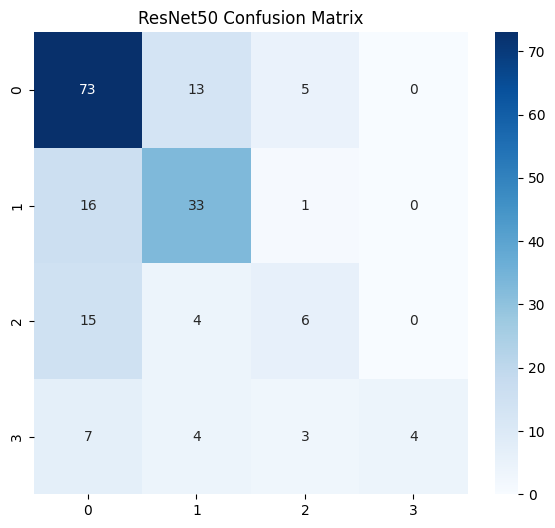

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_true_file, y_pred_file)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues')
plt.title("ResNet50 Confusion Matrix")
plt.show()


In [25]:
import numpy as np

mean = np.mean(X_train_res, axis=0)
std  = np.std(X_train_res, axis=0) + 1e-8

np.save("/kaggle/working/mean.npy", mean)
np.save("/kaggle/working/std.npy", std)

In [26]:
resnet_model.save("Aero_Resnet50.keras")


In [27]:
import zipfile

zip_path = "/kaggle/working/Aero_Resnet50.zip"

with zipfile.ZipFile(zip_path, 'w') as z:
    z.write("/kaggle/working/Aero_Resnet50.keras", arcname="model.keras")
    z.write("/kaggle/working/mean.npy", arcname="mean.npy")
    z.write("/kaggle/working/std.npy", arcname="std.npy")